In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 

In [61]:
# Load the dataset
data = pd.read_csv('Data_Set/final_proactive_malnutrition_data.csv',index_col=0)

In [62]:
data.head()

,Age_months,Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
ID,,,,,,,,,,,,,,,
0,59,Female,SNNPR,Primary,Middle,96.6,15.1,16.2,0,1,0,0,0,0,At_Risk
1,51,Male,Addis Ababa,No education,Low,84.5,11.2,15.7,1,1,1,0,1,1,Malnourished
2,37,Female,Addis Ababa,Secondary,Middle,83.0,9.8,14.2,0,1,0,1,0,0,At_Risk
3,12,Male,Tigray,Primary,Middle,58.7,5.8,16.8,0,0,0,1,0,0,Normal
4,6,Female,Addis Ababa,No education,Middle,48.4,2.7,11.5,1,1,1,0,1,0,Malnourished


In [63]:
data.shape

(5100, 15)

In [64]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age_months              5100 non-null   int64  
 1   Gender                  5100 non-null   str    
 2   Region                  5100 non-null   str    
 3   Mother_Education        5100 non-null   str    
 4   Household_Wealth_Index  5100 non-null   str    
 5   Height_cm               5100 non-null   float64
 6   Weight_kg               5100 non-null   float64
 7   BMI                     5100 non-null   float64
 8   Stunting                5100 non-null   int64  
 9   Underweight             5100 non-null   int64  
 10  Anemia                  5100 non-null   int64  
 11  Malaria                 5100 non-null   int64  
 12  Diarrhea                5100 non-null   int64  
 13  TB                      5100 non-null   int64  
 14  Nutrition_Status        5100 non-null   str    
dty

In [65]:
data.describe()

,Age_months,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB
count,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000,5100.000000
mean,29.806667,72.264647,8.852451,15.897941,0.422745,0.666667,0.336275,0.328627,0.333137,0.170392
std,17.613172,15.595584,4.270118,2.779951,0.494044,0.471451,0.472480,0.469760,0.471381,0.376014
min,0.000000,45.000000,2.200000,7.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,59.100000,5.400000,13.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,30.000000,71.850000,8.300000,15.900000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,85.000000,11.700000,17.700000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,60.000000,108.400000,21.900000,24.900000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [67]:
data.isna().sum()

Age_months                0
Gender                    0
Region                    0
Mother_Education          0
Household_Wealth_Index    0
Height_cm                 0
Weight_kg                 0
BMI                       0
Stunting                  0
Underweight               0
Anemia                    0
Malaria                   0
Diarrhea                  0
TB                        0
Nutrition_Status          0
dtype: int64

In [69]:
data.duplicated().any()

np.False_

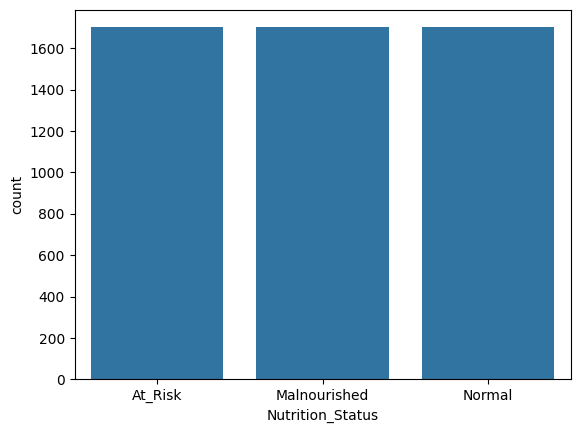

In [70]:
# EDA checking class imbalance
sns.countplot(x='Nutrition_Status', data=data)
plt.show()

In [71]:
data['Nutrition_Status'].value_counts()

Nutrition_Status
At_Risk         1700
Malnourished    1700
Normal          1700
Name: count, dtype: int64

In [72]:
data.columns

Index(['Age_months', 'Gender', 'Region', 'Mother_Education',
       'Household_Wealth_Index', 'Height_cm', 'Weight_kg', 'BMI', 'Stunting',
       'Underweight', 'Anemia', 'Malaria', 'Diarrhea', 'TB',
       'Nutrition_Status'],
      dtype='str')

In [73]:
# Encoding categorical variables
data['Gender'] = data['Gender'].map({
    'Male': 1,
    'Female': 0
})

In [74]:
data.head()

,Age_months,Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
ID,,,,,,,,,,,,,,,
0,59,0,SNNPR,Primary,Middle,96.6,15.1,16.2,0,1,0,0,0,0,At_Risk
1,51,1,Addis Ababa,No education,Low,84.5,11.2,15.7,1,1,1,0,1,1,Malnourished
2,37,0,Addis Ababa,Secondary,Middle,83.0,9.8,14.2,0,1,0,1,0,0,At_Risk
3,12,1,Tigray,Primary,Middle,58.7,5.8,16.8,0,0,0,1,0,0,Normal
4,6,0,Addis Ababa,No education,Middle,48.4,2.7,11.5,1,1,1,0,1,0,Malnourished


In [75]:
education_map = {
    'No education': 0,
    'Primary': 1,
    'Secondary': 2,
    'Higher': 3
}

data['Mother_Education'] = data['Mother_Education'].map(education_map)

In [76]:
data.head()

,Age_months,Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
ID,,,,,,,,,,,,,,,
0,59,0,SNNPR,1,Middle,96.6,15.1,16.2,0,1,0,0,0,0,At_Risk
1,51,1,Addis Ababa,0,Low,84.5,11.2,15.7,1,1,1,0,1,1,Malnourished
2,37,0,Addis Ababa,2,Middle,83.0,9.8,14.2,0,1,0,1,0,0,At_Risk
3,12,1,Tigray,1,Middle,58.7,5.8,16.8,0,0,0,1,0,0,Normal
4,6,0,Addis Ababa,0,Middle,48.4,2.7,11.5,1,1,1,0,1,0,Malnourished


In [77]:
data['Household_Wealth_Index'].unique()

<StringArray>
['Middle', 'Low', 'High']
Length: 3, dtype: str

In [78]:
wealth_map = {
    'Low': 0,
    'Middle': 1,
    'High': 2
}

data['Household_Wealth_Index'] = data['Household_Wealth_Index'].map(wealth_map)

In [79]:
data.head()


,Age_months,Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
ID,,,,,,,,,,,,,,,
0,59,0,SNNPR,1,1,96.6,15.1,16.2,0,1,0,0,0,0,At_Risk
1,51,1,Addis Ababa,0,0,84.5,11.2,15.7,1,1,1,0,1,1,Malnourished
2,37,0,Addis Ababa,2,1,83.0,9.8,14.2,0,1,0,1,0,0,At_Risk
3,12,1,Tigray,1,1,58.7,5.8,16.8,0,0,0,1,0,0,Normal
4,6,0,Addis Ababa,0,1,48.4,2.7,11.5,1,1,1,0,1,0,Malnourished


In [46]:
data.head()

,Age (months),Gender,Region,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Anemia,Malaria,Diarrhea,TB,Nutrition_Status
ID,,,,,,,,,,,,
0,53,1,Oromia,1,1,94.2,16.9,0,0,0,0,Normal
1,23,0,Addis Ababa,1,0,71.3,7.0,0,0,0,0,At_Risk
2,43,0,SNNPR,0,1,86.2,11.1,0,1,0,1,At_Risk
3,8,0,SNNPR,3,0,55.2,3.9,0,1,0,1,At_Risk
4,48,1,Tigray,3,2,92.4,9.0,1,0,1,0,Malnourished


In [80]:
data['Region'].unique() 

<StringArray>
['SNNPR', 'Addis Ababa', 'Tigray', 'Amhara', 'Oromia']
Length: 5, dtype: str

In [81]:
data= pd.get_dummies(data, columns=['Region'], drop_first=True)

In [82]:
data.head()

,Age_months,Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Nutrition_Status,Region_Amhara,Region_Oromia,Region_SNNPR,Region_Tigray
ID,,,,,,,,,,,,,,,,,,
0,59,0,1,1,96.6,15.1,16.2,0,1,0,0,0,0,At_Risk,False,False,True,False
1,51,1,0,0,84.5,11.2,15.7,1,1,1,0,1,1,Malnourished,False,False,False,False
2,37,0,2,1,83.0,9.8,14.2,0,1,0,1,0,0,At_Risk,False,False,False,False
3,12,1,1,1,58.7,5.8,16.8,0,0,0,1,0,0,Normal,False,False,False,True
4,6,0,0,1,48.4,2.7,11.5,1,1,1,0,1,0,Malnourished,False,False,False,False


In [83]:
bool_cols = data.select_dtypes(include='bool').columns
data[bool_cols] = data[bool_cols].astype(int)

In [51]:
data.head()

,Age (months),Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,Anemia,Malaria,Diarrhea,TB,Nutrition_Status,Region_Amhara,Region_Oromia,Region_SNNPR,Region_Tigray
ID,,,,,,,,,,,,,,,
0,53,1,1,1,94.2,16.9,0,0,0,0,Normal,0,1,0,0
1,23,0,1,0,71.3,7.0,0,0,0,0,At_Risk,0,0,0,0
2,43,0,0,1,86.2,11.1,0,1,0,1,At_Risk,0,0,1,0
3,8,0,3,0,55.2,3.9,0,1,0,1,At_Risk,0,0,1,0
4,48,1,3,2,92.4,9.0,1,0,1,0,Malnourished,0,0,0,1


In [84]:
# reorder the columns(bring the Nutrition_Status to the end)
cols = [col for col in data.columns if col != 'Nutrition_Status'] + ['Nutrition_Status']
data = data[cols]
data.head()

,Age_months,Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Region_Amhara,Region_Oromia,Region_SNNPR,Region_Tigray,Nutrition_Status
ID,,,,,,,,,,,,,,,,,,
0,59,0,1,1,96.6,15.1,16.2,0,1,0,0,0,0,0,0,1,0,At_Risk
1,51,1,0,0,84.5,11.2,15.7,1,1,1,0,1,1,0,0,0,0,Malnourished
2,37,0,2,1,83.0,9.8,14.2,0,1,0,1,0,0,0,0,0,0,At_Risk
3,12,1,1,1,58.7,5.8,16.8,0,0,0,1,0,0,0,0,0,1,Normal
4,6,0,0,1,48.4,2.7,11.5,1,1,1,0,1,0,0,0,0,0,Malnourished


In [85]:
# Encoding the target variable
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Nutrition_Status'] = le.fit_transform(data['Nutrition_Status'])

In [87]:
data.head(30)

,Age_months,Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Region_Amhara,Region_Oromia,Region_SNNPR,Region_Tigray,Nutrition_Status
ID,,,,,,,,,,,,,,,,,,
0,59,0,1,1,96.6,15.1,16.2,0,1,0,0,0,0,0,0,1,0,0
1,51,1,0,0,84.5,11.2,15.7,1,1,1,0,1,1,0,0,0,0,1
2,37,0,2,1,83.0,9.8,14.2,0,1,0,1,0,0,0,0,0,0,0
3,12,1,1,1,58.7,5.8,16.8,0,0,0,1,0,0,0,0,0,1,2
4,6,0,0,1,48.4,2.7,11.5,1,1,1,0,1,0,0,0,0,0,1
5,44,1,1,0,79.7,7.6,12.0,1,1,1,1,1,0,1,0,0,0,1
6,41,1,0,0,75.9,7.7,13.4,1,1,1,1,0,0,0,0,0,1,1
7,57,0,1,1,100.8,19.0,18.7,0,0,0,0,0,0,0,0,1,0,2
8,42,1,2,1,80.8,11.0,16.8,0,1,1,0,0,0,0,0,0,1,0


In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Features
X = data.drop(columns=['Nutrition_Status'])
y = data['Nutrition_Status']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)
y_pred
 

array([2, 0, 1, ..., 2, 1, 1], shape=(1020,))

In [89]:
X_test.head()

,Age_months,Gender,Mother_Education,Household_Wealth_Index,Height_cm,Weight_kg,BMI,Stunting,Underweight,Anemia,Malaria,Diarrhea,TB,Region_Amhara,Region_Oromia,Region_SNNPR,Region_Tigray
ID,,,,,,,,,,,,,,,,,
4039,19,0,1,1,67.7,9.3,20.3,0,0,0,0,0,0,0,0,0,1
3815,4,0,1,2,55.0,3.7,12.2,0,1,0,0,0,0,0,0,0,1
848,16,0,2,0,61.4,4.6,12.2,1,1,1,0,1,1,1,0,0,0
4863,48,0,0,0,82.3,8.9,13.1,1,1,0,0,1,0,1,0,0,0
79,1,1,1,2,52.5,4.4,16.0,0,0,1,0,0,0,0,0,1,0


In [90]:
y_test.head()

ID
4039    2
3815    0
848     1
4863    1
79      2
Name: Nutrition_Status, dtype: int64